#**Calling important libraries**

In [3]:
# importing libraries like google drive
# pandas
# matplotlib and seaborn
# numpy

import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

**calling the dataset**

In [ ]:
epma2 = pd.read_excel('/content/dataset epma preprocessed1.xlsx',
                      sheet_name='Sheet1')

epma2.dtypes

epma2['T'] = epma2['T'].astype(float)

epma2.dtypes

#**splitting the data**

In [5]:
#for splitting the dataframes

from sklearn.model_selection import train_test_split, StratifiedKFold

# for calling the models
from sklearn.ensemble import RandomForestClassifier

from sklearn.linear_model import LogisticRegression

#for calling the model performance metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


In [6]:
# Defining the dataframe into X features and y target label

X = epma2.drop(columns=['T'])
y = epma2['T']


In [7]:
#for splitting the dataframes

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,

                                                    stratify=y, #applying stratified splitting to ensure proportional representation of target classes in training and test sets.

                                                    random_state=42)


#**Applying logistic regression to it with k fold cross validation**


Stratified K-Fold Cross-Validation Results:


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



Fold 1:
Accuracy: 0.6716
Precision: 0.6830
Recall: 0.6716
F1-Score: 0.6429
Confusion Matrix:
[[21  4  0]
 [ 7 22  1]
 [ 7  3  2]]


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



Fold 2:
Accuracy: 0.5821
Precision: 0.6735
Recall: 0.5821
F1-Score: 0.5717
Confusion Matrix:
[[19  6  0]
 [13 17  0]
 [ 8  1  3]]


...


Fold 4:
Accuracy: 0.6418
Precision: 0.5616
Recall: 0.6418
F1-Score: 0.5908
Confusion Matrix:
[[21  4  1]
 [ 7 22  0]
 [11  1  0]]


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



Fold 5:
Accuracy: 0.7576
Precision: 0.7940
Recall: 0.7576
F1-Score: 0.7345
Confusion Matrix:
[[20  6  0]
 [ 2 27  0]
 [ 3  5  3]]

Average Metrics Across All Folds:
Accuracy: 0.6769
Precision: 0.6860
Recall: 0.6769
F1-Score: 0.6499


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



EPMA Test Set Metrics of Ensemble 1 model:
Accuracy: 0.7976
Precision: 0.7993
Recall: 0.7976
F1-Score: 0.7709

Classification Report (Test Set):
               precision    recall  f1-score   support

         1.0       0.77      0.94      0.85        32
         2.0       0.82      0.89      0.86        37
         3.0       0.80      0.27      0.40        15

    accuracy                           0.80        84
   macro avg       0.80      0.70      0.70        84
weighted avg       0.80      0.80      0.77        84



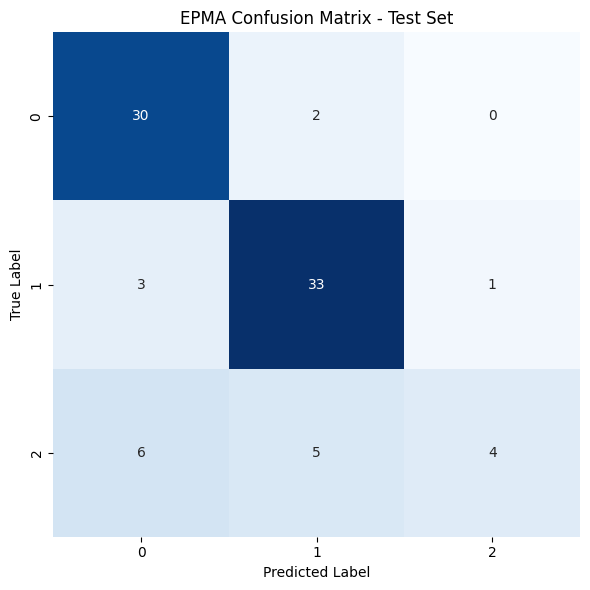

In [13]:
######################################################################

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns

# Separate features and target
X = epma2.drop('T', axis=1)  # Features
y = epma2['T']               # Target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=48
)

# Define individual models
logistic = LogisticRegression(
    C=0.8, penalty='l1', solver='saga', max_iter=200
)
random_forest = RandomForestClassifier(
    n_estimators=200, max_depth=12, min_samples_split=6,
    class_weight='balanced', random_state=42
)

# Create an ensemble model with max voting
voting_model = VotingClassifier(
    estimators=[('lr', logistic), ('rf', random_forest)],
    voting='hard'
)

# Stratified K-Fold Cross-Validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store metrics
fold_accuracies = []
fold_precisions = []
fold_recalls = []
fold_f1_scores = []
fold_confusion_matrices = []

print("\nStratified K-Fold Cross-Validation Results:")

for fold, (train_index, val_index) in enumerate(kf.split(X_train, y_train)):
    # Split data into training and validation subsets
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    # Train the ensemble model
    voting_model.fit(X_train_fold, y_train_fold)

    # Validate the model
    y_val_pred = voting_model.predict(X_val_fold)

    # Calculate metrics
    accuracy = accuracy_score(y_val_fold, y_val_pred)
    precision = precision_score(y_val_fold, y_val_pred, average="weighted")
    recall = recall_score(y_val_fold, y_val_pred, average="weighted")
    f1 = f1_score(y_val_fold, y_val_pred, average="weighted")
    confusion = confusion_matrix(y_val_fold, y_val_pred)

    # Append metrics
    fold_accuracies.append(accuracy)
    fold_precisions.append(precision)
    fold_recalls.append(recall)
    fold_f1_scores.append(f1)
    fold_confusion_matrices.append(confusion)

    # Print metrics for each fold
    print(f"\nFold {fold + 1}:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"Confusion Matrix:\n{confusion}")

# Calculate average metrics across folds
avg_accuracy = sum(fold_accuracies) / len(fold_accuracies)
avg_precision = sum(fold_precisions) / len(fold_precisions)
avg_recall = sum(fold_recalls) / len(fold_recalls)
avg_f1_score = sum(fold_f1_scores) / len(fold_f1_scores)

print("\nAverage Metrics Across All Folds:")
print(f"Accuracy: {avg_accuracy:.4f}")
print(f"Precision: {avg_precision:.4f}")
print(f"Recall: {avg_recall:.4f}")
print(f"F1-Score: {avg_f1_score:.4f}")

# Test Set Evaluation
voting_model.fit(X_train, y_train)  # Train on the entire training set
y_test_pred = voting_model.predict(X_test)  # Predict on the test set

# Test set metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average="weighted")
test_recall = recall_score(y_test, y_test_pred, average="weighted")
test_f1 = f1_score(y_test, y_test_pred, average="weighted")
test_confusion = confusion_matrix(y_test, y_test_pred)

print("\nEPMA Test Set Metrics of Ensemble 1 model:")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1-Score: {test_f1:.4f}")
#print("\nConfusion Matrix (Test Set):\n", test_confusion)
print("\nClassification Report (Test Set):\n", classification_report(y_test, y_test_pred))

# Plot confusion matrix for the test set
plt.figure(figsize=(6, 6))
sns.heatmap(test_confusion, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('EPMA Confusion Matrix - Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()



#######################################################

In [ ]:
# for calling the models

from sklearn.linear_model import LogisticRegression

#for calling the model performance metrics
from sklearn.metrics import accuracy_score

# defining the function train_and_evaluate

# it takes the argument X_train_fold, y_train_fold, X_val_fold and y_val_fold

def train_and_evaluate(X_train_fold, y_train_fold, X_val_fold, y_val_fold):
    """
    it Train and evaluate the model on a single fold using Logistic Regression.
    """
    # Train the model

    model = LogisticRegression(random_state=42,
                               max_iter=1000)  # Increased max_iter for convergence

    model.fit(X_train_fold, y_train_fold)

    # Validate the model

    y_val_pred = model.predict(X_val_fold) # prediction on X_val_fold

    accuracy = accuracy_score(y_val_fold, y_val_pred) # where y_val_pred = model.predict(X_val_fold)

    return accuracy

###########################################################################################################################

from sklearn.model_selection import StratifiedKFold

# Placeholder for metrics

fold_precisions = []

fold_recalls = []

fold_f1_scores = []

fold_confusion_matrices = []

fold_accuracies = []

fold_models = []  # Store models for each fold

# Define Stratified K-Fold as kf where,

kf = StratifiedKFold(n_splits=5,
                     shuffle=True,
                     random_state=42)


# Loop through the folds
for fold, (train_index, val_index) in enumerate( kf.split( X_train, y_train ) ):

    # Split the data into training and validation subsets

    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]

    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    # Call the training function

    accuracy = train_and_evaluate(X_train_fold,
                                  y_train_fold,
                                  X_val_fold,
                                  y_val_fold)

    fold_accuracies.append(accuracy)

    # Train model and save it for later use

    model = LogisticRegression(random_state=42, max_iter=1000)

    model.fit(X_train_fold, y_train_fold)

    fold_models.append(model)  # Save the trained model

    print(f"Fold {fold + 1} Accuracy: {accuracy:.4f}")

    # Validate and calculate additional metrics
    y_val_pred = model.predict(X_val_fold)

    precision = precision_score(y_val_fold, y_val_pred, average="weighted")
    recall = recall_score(y_val_fold, y_val_pred, average="weighted")
    f1 = f1_score(y_val_fold, y_val_pred, average="weighted")
    confusion = confusion_matrix(y_val_fold, y_val_pred)

    fold_precisions.append(precision)
    fold_recalls.append(recall)
    fold_f1_scores.append(f1)
    fold_confusion_matrices.append(confusion)

    print(f"Fold {fold + 1} Metrics:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  Confusion Matrix:\n{confusion}\n")

# Calculate average metrics
avg_accuracy = sum(fold_accuracies) / len(fold_accuracies)
avg_precision = sum(fold_precisions) / len(fold_precisions)
avg_recall = sum(fold_recalls) / len(fold_recalls)
avg_f1_score = sum(fold_f1_scores) / len(fold_f1_scores)


# Calculate the average accuracy across all folds

print("Average Metrics Across All Folds:")
print(f"  Accuracy: {avg_accuracy:.4f}")
print(f"  Precision: {avg_precision:.4f}")
print(f"  Recall: {avg_recall:.4f}")
print(f"  F1-Score: {avg_f1_score:.4f}")



import matplotlib.pyplot as plt

# Calculate the average accuracy across all folds

avg_accuracy = sum(fold_accuracies) / len(fold_accuracies)

print(f"Average CV Accuracy: {avg_accuracy:.4f}")


# Visualization

folds = list(range(1,
                   len(fold_accuracies) + 1))

# Bar plot for individual fold accuracies

plt.bar(folds,
        fold_accuracies,
        alpha=0.7,
        label="Fold Accuracy")

plt.axhline(avg_accuracy,

            color= 'red',

            linestyle= '--',

            label= f"Avg Accuracy: {avg_accuracy:.4f}" )

# Add labels and title

plt.xlabel("Fold Number")

plt.ylabel("Accuracy")

plt.title("Cross-Validation Fold Accuracies")

plt.xticks(folds)

plt.legend()

# Show plot

plt.show()


# Use the model for Fold 3 to check for mislabeling
fold_3_model = fold_models[2]  # Model from Fold 3 (index starts at 0)
y_val_pred = fold_3_model.predict(X_val_fold)

# Identify mismatches in Fold 3
mismatches = X_val_fold[y_val_pred != y_val_fold]
mismatched_labels = y_val_fold[y_val_pred != y_val_fold]

# Display mismatched rows
print("Mislabeled samples in Fold 3:")
print(mismatches)
print("True labels:", mismatched_labels)
print("Predicted labels:", y_val_pred[y_val_pred != y_val_fold])



Fold 1 Metrics:
  Accuracy: 0.7015
  Precision: 0.6850
  Recall: 0.7015
  F1-Score: 0.6840
  AUC-ROC: 0.8078
  Confusion Matrix:
[[18  4  3]
 [ 4 26  0]
 [ 7  2  3]]

Fold 2 Metrics:
  Accuracy: 0.6866
  Precision: 0.6582
  Recall: 0.6866
  F1-Score: 0.6639
  AUC-ROC: 0.8616
  Confusion Matrix:
[[19  6  1]
 [ 3 25  2]
 [ 6  3  2]]

Fold 3 Metrics:
  Accuracy: 0.5522
  Precision: 0.5082
  Recall: 0.5522
  F1-Score: 0.5191
  AUC-ROC: 0.7711
  Confusion Matrix:
[[13 11  2]
 [ 5 23  1]
 [ 9  2  1]]

Fold 4 Metrics:
  Accuracy: 0.8209
  Precision: 0.8224
  Recall: 0.8209
  F1-Score: 0.8073
  AUC-ROC: 0.8808
  Confusion Matrix:
[[22  3  1]
 [ 1 28  0]
 [ 6  1  5]]

Fold 5 Metrics:
  Accuracy: 0.6970
  Precision: 0.7047
  Recall: 0.6970
  F1-Score: 0.6750
  AUC-ROC: 0.8266
  Confusion Matrix:
[[20  5  0]
 [ 5 23  1]
 [ 5  4  3]]

Average Metrics Across All Folds:
  Accuracy: 0.6916
  Precision: 0.6757
  Recall: 0.6916
  F1-Score: 0.6699
  AUC-ROC: 0.8296


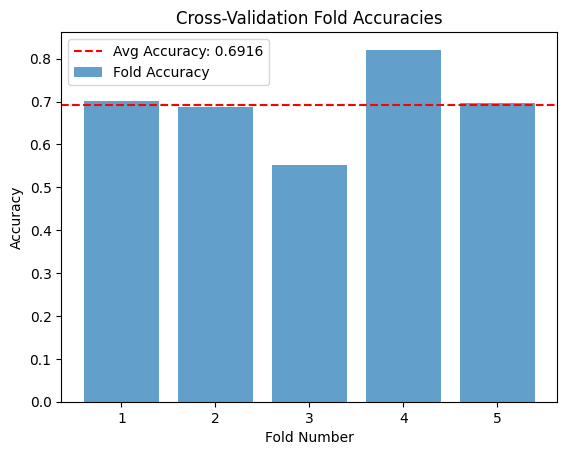

Mislabeled samples in Fold 3:
          NiO         F     Cr2O3      Na2O       MnO       ZnO       FeO  \
320  0.059524  0.000000  0.067893  0.134772  0.259649  0.897436  0.122171   
403  0.167464  0.000000  0.021856  0.263918  0.260833  0.000000  0.324215   
245  0.000000  0.614350  0.226308  0.251459  0.061404  0.000000  0.158750   
314  0.000000  0.327354  0.130127  0.179113  0.168421  0.115385  0.256933   
136  0.297619  0.233184  0.596888  0.230455  0.040351  0.000000  0.058256   
370  0.238095  0.282511  0.405941  0.233956  0.045614  0.570513  0.024785   
129  0.238095  0.000000  0.107496  0.292299  0.147368  0.000000  0.234778   
278  0.107143  0.125561  0.407355  0.236873  0.056140  0.153846  0.119142   
40   0.000000  0.000000  0.444884  0.310742  0.172693  0.000000  0.166554   
93   0.428571  0.000000  0.206506  0.277130  0.228070  0.096154  0.147673   
41   0.000000  0.000000  0.091938  0.382147  0.235088  0.000000  0.391935   
235  0.000000  0.426009  0.104668  0.395566  0

In [ ]:



from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

# Placeholder for metrics
fold_precisions = []
fold_recalls = []
fold_f1_scores = []
fold_auc_rocs = []
fold_confusion_matrices = []
fold_accuracies = []
fold_models = []

# Define Stratified K-Fold
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Loop through the folds
for fold, (train_index, val_index) in enumerate(kf.split(X_train, y_train)):
    # Split the data into training and validation subsets
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    # Train model
    model = LogisticRegression(random_state=42, max_iter=1000)
    model.fit(X_train_fold, y_train_fold)

    # Save the trained model
    fold_models.append(model)

    # Validate and calculate metrics
    y_val_pred = model.predict(X_val_fold)

    y_val_prob = model.predict_proba(X_val_fold)[:, 1]  # For AUC-ROC calculation

    accuracy = accuracy_score(y_val_fold, y_val_pred)

    precision = precision_score(y_val_fold, y_val_pred, average="weighted")

    recall = recall_score(y_val_fold, y_val_pred, average="weighted")

    f1 = f1_score(y_val_fold, y_val_pred, average="weighted")

    # Check if binary classification or multi-class classification
    if len(set(y_val_fold)) > 2:

    # Multi-class AUC-ROC
        y_val_prob = model.predict_proba(X_val_fold)

        auc_roc = roc_auc_score(y_val_fold, y_val_prob, average="weighted", multi_class='ovr')

    else:

    # Binary classification AUC-ROC
        y_val_prob = model.predict_proba(X_val_fold)[:, 1]  # Use probabilities for the positive class

        auc_roc = roc_auc_score(y_val_fold, y_val_prob)


    auc_roc = roc_auc_score(y_val_fold, y_val_prob, average="weighted", multi_class='ovr') if len(set(y_val_fold)) > 2 else roc_auc_score(y_val_fold, y_val_prob)

    confusion = confusion_matrix(y_val_fold, y_val_pred)

    # Append metrics
    fold_accuracies.append(accuracy)
    fold_precisions.append(precision)
    fold_recalls.append(recall)
    fold_f1_scores.append(f1)
    fold_auc_rocs.append(auc_roc)
    fold_confusion_matrices.append(confusion)

    # Print metrics for the fold
    print(f"Fold {fold + 1} Metrics:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  AUC-ROC: {auc_roc:.4f}")
    print(f"  Confusion Matrix:\n{confusion}\n")



# Calculate average metrics across all folds
avg_accuracy = sum(fold_accuracies) / len(fold_accuracies)
avg_precision = sum(fold_precisions) / len(fold_precisions)
avg_recall = sum(fold_recalls) / len(fold_recalls)
avg_f1_score = sum(fold_f1_scores) / len(fold_f1_scores)
avg_auc_roc = sum(fold_auc_rocs) / len(fold_auc_rocs)


print("Average Metrics Across All Folds:")
print(f"  Accuracy: {avg_accuracy:.4f}")
print(f"  Precision: {avg_precision:.4f}")
print(f"  Recall: {avg_recall:.4f}")
print(f"  F1-Score: {avg_f1_score:.4f}")
print(f"  AUC-ROC: {avg_auc_roc:.4f}")

# Visualization of fold accuracies
folds = list(range(1, len(fold_accuracies) + 1))
plt.bar(folds, fold_accuracies, alpha=0.7, label="Fold Accuracy")
plt.axhline(avg_accuracy, color='red', linestyle='--', label=f"Avg Accuracy: {avg_accuracy:.4f}")
plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.title("Cross-Validation Fold Accuracies")
plt.xticks(folds)
plt.legend()
plt.show()

# Use the model for Fold 3 to check for mislabeling
fold_3_model = fold_models[2]  # Model from Fold 3 (index starts at 0)
y_val_pred = fold_3_model.predict(X_val_fold)

# Identify mismatches in Fold 3
mismatches = X_val_fold[y_val_pred != y_val_fold]
mismatched_labels = y_val_fold[y_val_pred != y_val_fold]

# Display mismatched rows
print("Mislabeled samples in Fold 3:")
print(mismatches)
print("True labels:", mismatched_labels)
print("Predicted labels:", y_val_pred[y_val_pred != y_val_fold])


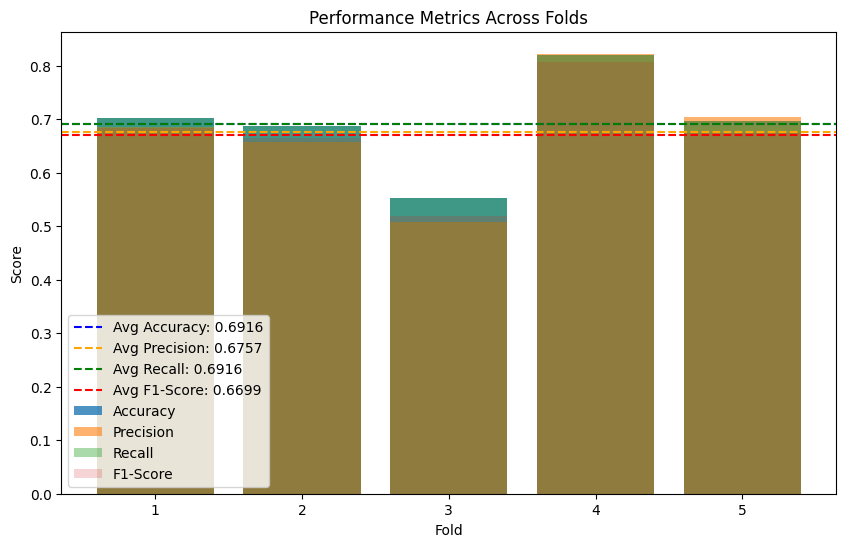

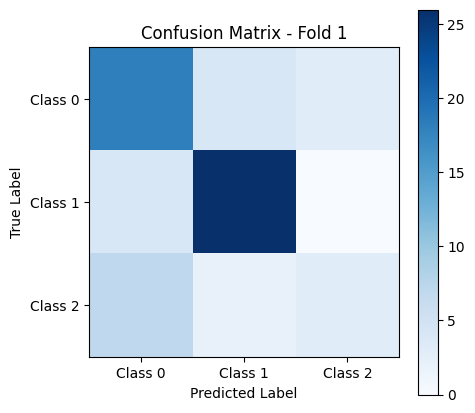

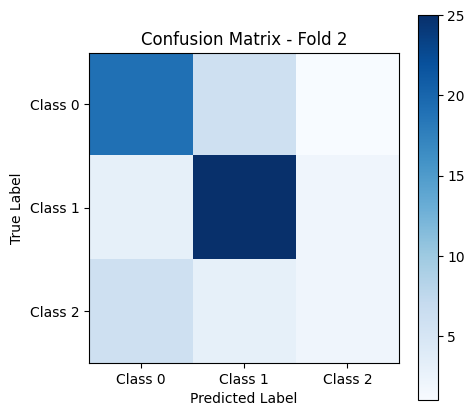

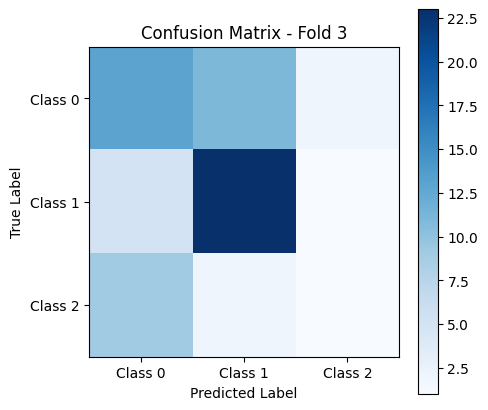

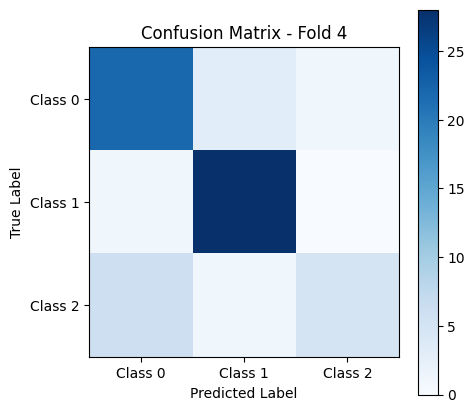

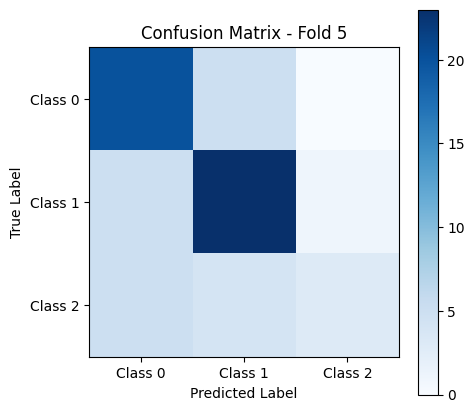

In [ ]:
# Plotting metrics for each fold
folds = range(1, len(fold_accuracies) + 1)
plt.figure(figsize=(10, 6))

# Bar chart for Accuracy, Precision, Recall, and F1-Score
plt.bar(folds, fold_accuracies, alpha=0.8, label='Accuracy')
plt.bar(folds, fold_precisions, alpha=0.6, label='Precision')
plt.bar(folds, fold_recalls, alpha=0.4, label='Recall')
plt.bar(folds, fold_f1_scores, alpha=0.2, label='F1-Score')

plt.axhline(avg_accuracy, color='blue', linestyle='--', label=f'Avg Accuracy: {avg_accuracy:.4f}')
plt.axhline(avg_precision, color='orange', linestyle='--', label=f'Avg Precision: {avg_precision:.4f}')
plt.axhline(avg_recall, color='green', linestyle='--', label=f'Avg Recall: {avg_recall:.4f}')
plt.axhline(avg_f1_score, color='red', linestyle='--', label=f'Avg F1-Score: {avg_f1_score:.4f}')

# Labels and legend
plt.xlabel('Fold')
plt.ylabel('Score')
plt.title('Performance Metrics Across Folds')
plt.xticks(folds)
plt.legend()
plt.show()

for fold, confusion in enumerate(fold_confusion_matrices, start=1):
    plt.figure(figsize=(5, 5))
    plt.imshow(confusion, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix - Fold {fold}')
    plt.colorbar()

    # Dynamically set ticks and labels based on the number of classes
    classes = range(confusion.shape[0])
    plt.xticks(classes, labels=[f'Class {i}' for i in classes])
    plt.yticks(classes, labels=[f'Class {i}' for i in classes])

    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

#**applying random forrest classifier**

Fold 1 Metrics:
  Accuracy: 0.7164
  Precision: 0.6955
  Recall: 0.7164
  F1-Score: 0.6968
Fold 2 Metrics:
  Accuracy: 0.7761
  Precision: 0.7787
  Recall: 0.7761
  F1-Score: 0.7621
Fold 3 Metrics:
  Accuracy: 0.7015
  Precision: 0.7339
  Recall: 0.7015
  F1-Score: 0.6874
Fold 4 Metrics:
  Accuracy: 0.7612
  Precision: 0.7826
  Recall: 0.7612
  F1-Score: 0.7605
Fold 5 Metrics:
  Accuracy: 0.6515
  Precision: 0.6326
  Recall: 0.6515
  F1-Score: 0.6366

Average Metrics Across All Folds:
  Accuracy: 0.7213
  Precision: 0.7247
  Recall: 0.7213
  F1-Score: 0.7087

Test Set Metrics:
  Accuracy: 0.6786
  Precision: 0.6995
  Recall: 0.6786
  F1-Score: 0.6671


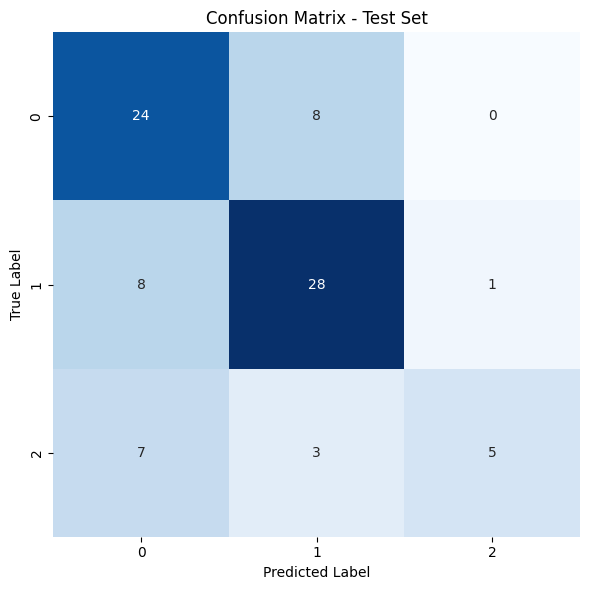

In [ ]:
#####################################################################

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Load dataset (assuming `epma2` is already loaded)
X = epma2.drop(columns=['T'])
y = epma2['T']

# Split dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Function to train and evaluate the model
def train_and_evaluate(X_train_fold, y_train_fold, X_val_fold, y_val_fold):
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train_fold, y_train_fold)
    y_val_pred = model.predict(X_val_fold)
    accuracy = accuracy_score(y_val_fold, y_val_pred)
    return accuracy, model

# Stratified K-Fold Cross-Validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_accuracies = []
fold_metrics = {
    'precision': [],
    'recall': [],
    'f1_score': [],
    'confusion_matrices': []
}
best_model = None
best_accuracy = 0

for fold, (train_index, val_index) in enumerate(kf.split(X_train, y_train)):
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    accuracy, model = train_and_evaluate(X_train_fold, y_train_fold, X_val_fold, y_val_fold)
    fold_accuracies.append(accuracy)

    # Validate and calculate additional metrics
    y_val_pred = model.predict(X_val_fold)
    precision = precision_score(y_val_fold, y_val_pred, average="weighted")
    recall = recall_score(y_val_fold, y_val_pred, average="weighted")
    f1 = f1_score(y_val_fold, y_val_pred, average="weighted")
    confusion = confusion_matrix(y_val_fold, y_val_pred)

    fold_metrics['precision'].append(precision)
    fold_metrics['recall'].append(recall)
    fold_metrics['f1_score'].append(f1)
    fold_metrics['confusion_matrices'].append(confusion)

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model

    print(f"Fold {fold + 1} Metrics:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")

# Average Metrics Across Folds
avg_accuracy = np.mean(fold_accuracies)
avg_precision = np.mean(fold_metrics['precision'])
avg_recall = np.mean(fold_metrics['recall'])
avg_f1_score = np.mean(fold_metrics['f1_score'])

print("\nAverage Metrics Across All Folds:")
print(f"  Accuracy: {avg_accuracy:.4f}")
print(f"  Precision: {avg_precision:.4f}")
print(f"  Recall: {avg_recall:.4f}")
print(f"  F1-Score: {avg_f1_score:.4f}")

# Save the best model
joblib.dump(best_model, 'best_random_forest_model.pkl')

# Test Set Evaluation
y_test_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')
test_confusion = confusion_matrix(y_test, y_test_pred)

print("\nTest Set Metrics:")
print(f"  Accuracy: {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall: {test_recall:.4f}")
print(f"  F1-Score: {test_f1:.4f}")

# Plot Test Confusion Matrix
plt.figure(figsize=(6, 6))
sns.heatmap(test_confusion, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()




##################################################################

#**ensemble models**

In [ ]:
epma2['T'] = epma2['T'].astype(float)


Stratified K-Fold Cross-Validation Results:


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



Fold 1:
Accuracy: 0.6716
Precision: 0.6830
Recall: 0.6716
F1-Score: 0.6429
Confusion Matrix:
[[21  4  0]
 [ 7 22  1]
 [ 7  3  2]]


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



Fold 2:
Accuracy: 0.5821
Precision: 0.6735
Recall: 0.5821
F1-Score: 0.5717
Confusion Matrix:
[[19  6  0]
 [13 17  0]
 [ 8  1  3]]


...


Fold 4:
Accuracy: 0.6418
Precision: 0.5616
Recall: 0.6418
F1-Score: 0.5908
Confusion Matrix:
[[21  4  1]
 [ 7 22  0]
 [11  1  0]]


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



Fold 5:
Accuracy: 0.7576
Precision: 0.7940
Recall: 0.7576
F1-Score: 0.7345
Confusion Matrix:
[[20  6  0]
 [ 2 27  0]
 [ 3  5  3]]

Average Metrics Across All Folds:
Accuracy: 0.6769
Precision: 0.6860
Recall: 0.6769
F1-Score: 0.6499


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



Test Set Metrics:
Accuracy: 0.7976
Precision: 0.7993
Recall: 0.7976
F1-Score: 0.7709

Confusion Matrix (Test Set):
 [[30  2  0]
 [ 3 33  1]
 [ 6  5  4]]

Classification Report (Test Set):
               precision    recall  f1-score   support

         1.0       0.77      0.94      0.85        32
         2.0       0.82      0.89      0.86        37
         3.0       0.80      0.27      0.40        15

    accuracy                           0.80        84
   macro avg       0.80      0.70      0.70        84
weighted avg       0.80      0.80      0.77        84



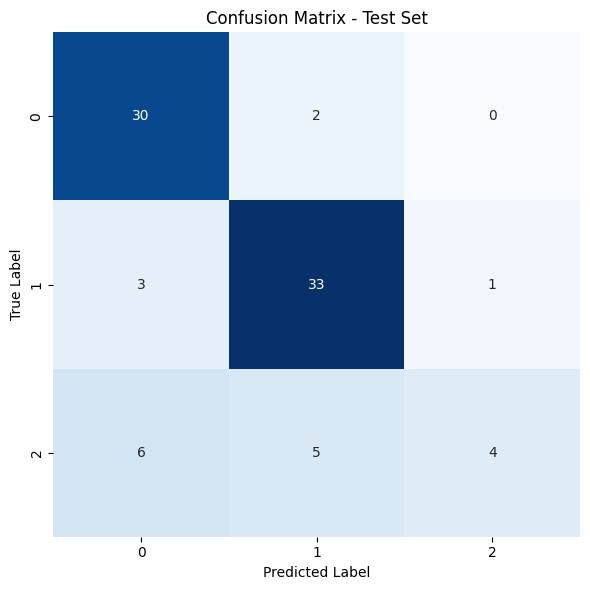

In [ ]:
#############################################################################################################

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns

# Separate features and target
X = epma2.drop('T', axis=1)  # Features
y = epma2['T']               # Target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=48
)

# Define individual models
logistic = LogisticRegression(
    C=0.8, penalty='l1', solver='saga', max_iter=200
)
random_forest = RandomForestClassifier(
    n_estimators=200, max_depth=12, min_samples_split=6,
    class_weight='balanced', random_state=42
)

# Create an ensemble model with max voting
voting_model = VotingClassifier(
    estimators=[('lr', logistic), ('rf', random_forest)],
    voting='hard'
)

# Stratified K-Fold Cross-Validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store metrics
fold_accuracies = []
fold_precisions = []
fold_recalls = []
fold_f1_scores = []
fold_confusion_matrices = []

print("\nStratified K-Fold Cross-Validation Results:")

for fold, (train_index, val_index) in enumerate(kf.split(X_train, y_train)):
    # Split data into training and validation subsets
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    # Train the ensemble model
    voting_model.fit(X_train_fold, y_train_fold)

    # Validate the model
    y_val_pred = voting_model.predict(X_val_fold)

    # Calculate metrics
    accuracy = accuracy_score(y_val_fold, y_val_pred)
    precision = precision_score(y_val_fold, y_val_pred, average="weighted")
    recall = recall_score(y_val_fold, y_val_pred, average="weighted")
    f1 = f1_score(y_val_fold, y_val_pred, average="weighted")
    confusion = confusion_matrix(y_val_fold, y_val_pred)

    # Append metrics
    fold_accuracies.append(accuracy)
    fold_precisions.append(precision)
    fold_recalls.append(recall)
    fold_f1_scores.append(f1)
    fold_confusion_matrices.append(confusion)

    # Print metrics for each fold
    print(f"\nFold {fold + 1}:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"Confusion Matrix:\n{confusion}")

# Calculate average metrics across folds
avg_accuracy = sum(fold_accuracies) / len(fold_accuracies)
avg_precision = sum(fold_precisions) / len(fold_precisions)
avg_recall = sum(fold_recalls) / len(fold_recalls)
avg_f1_score = sum(fold_f1_scores) / len(fold_f1_scores)

print("\nAverage Metrics Across All Folds:")
print(f"Accuracy: {avg_accuracy:.4f}")
print(f"Precision: {avg_precision:.4f}")
print(f"Recall: {avg_recall:.4f}")
print(f"F1-Score: {avg_f1_score:.4f}")

# Test Set Evaluation
voting_model.fit(X_train, y_train)  # Train on the entire training set
y_test_pred = voting_model.predict(X_test)  # Predict on the test set

# Test set metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average="weighted")
test_recall = recall_score(y_test, y_test_pred, average="weighted")
test_f1 = f1_score(y_test, y_test_pred, average="weighted")
test_confusion = confusion_matrix(y_test, y_test_pred)

print("\nTest Set Metrics:")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1-Score: {test_f1:.4f}")
print("\nConfusion Matrix (Test Set):\n", test_confusion)
print("\nClassification Report (Test Set):\n", classification_report(y_test, y_test_pred))

# Plot confusion matrix for the test set
plt.figure(figsize=(6, 6))
sns.heatmap(test_confusion, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()





##########################################################################################################

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Ensemble Model Accuracy: 0.80
Precision: 0.80
Recall (Sensitivity): 0.80
F1 Score: 0.77
AUC-ROC: 0.89
Confusion Matrix:
[[29  3  0]
 [ 3 33  1]
 [ 5  5  5]]


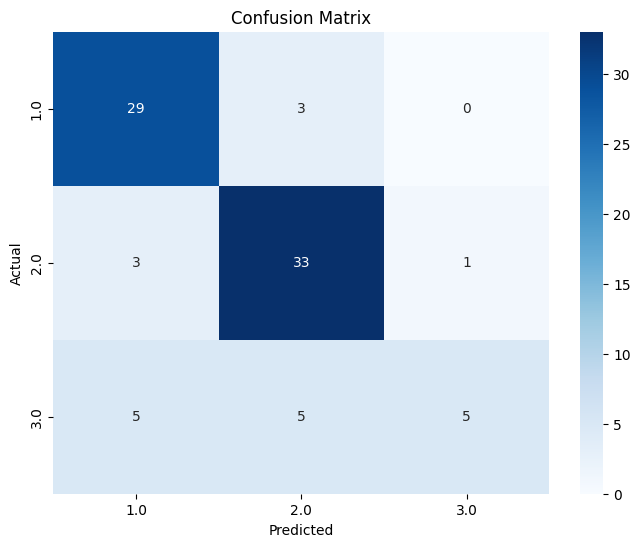

In [ ]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Update VotingClassifier to use soft voting
voting_model = VotingClassifier(
    estimators=[('lr', logistic), ('rf', random_forest)],
    voting='soft'  # Soft voting to enable predict_proba
)

# Train the ensemble model
voting_model.fit(X_train, y_train)

# Make predictions
y_pred = voting_model.predict(X_test)
y_prob = voting_model.predict_proba(X_test)  # Use predict_proba for AUC-ROC

# Evaluate AUC-ROC
if len(set(y_test)) > 2:  # Multi-class classification
    auc_roc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')
else:  # Binary classification
    auc_roc = roc_auc_score(y_test, y_prob[:, 1])  # Use positive class probabilities

# Print metrics
print(f"Ensemble Model Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall (Sensitivity): {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
print(f"AUC-ROC: {auc_roc:.2f}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Plot ROC Curve
if len(set(y_test)) <= 2:  # Only for binary classification
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"AUC-ROC: {auc_roc:.2f}")
    plt.plot([0, 1], [0, 1], 'r--', label="Random Classifier")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()


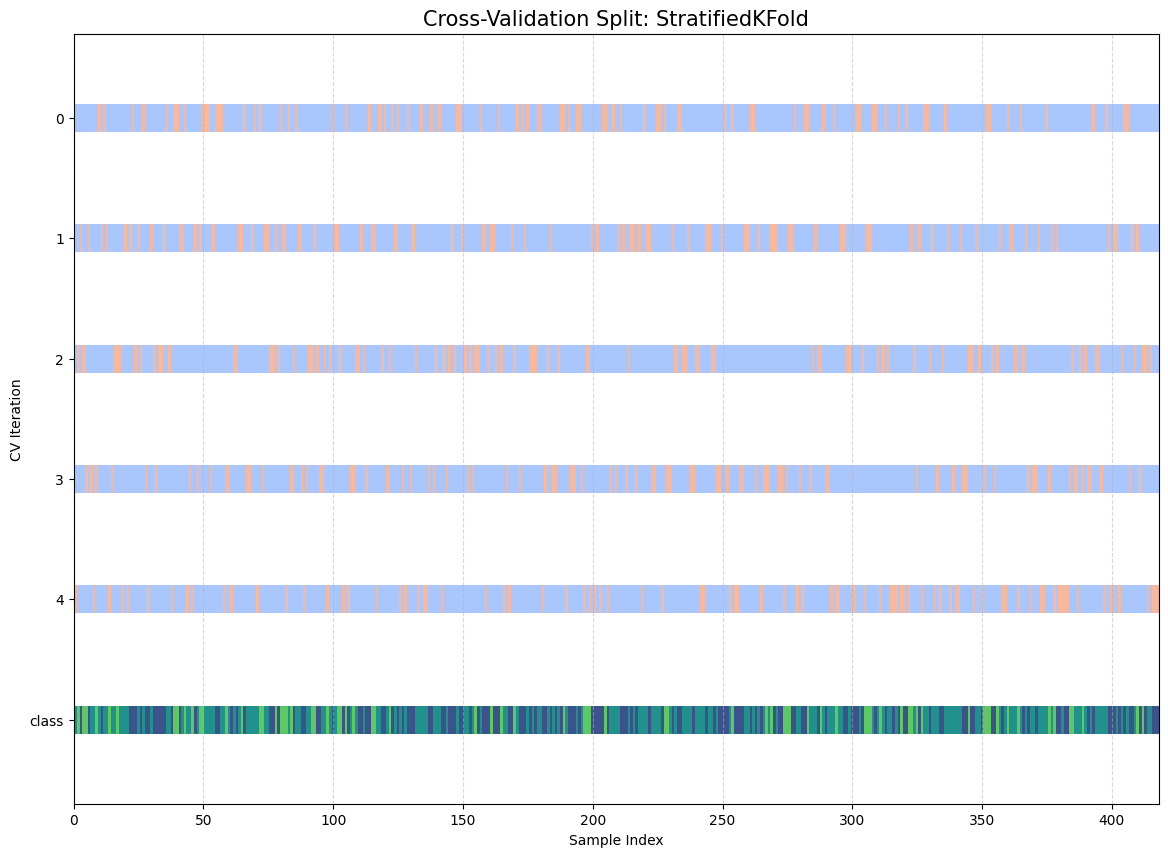

In [ ]:
# Modify the function to produce thicker bars and include additional information in the plot
def plot_cv_indices_thick(cv, X, y, ax, n_splits, lw=20):
    """Create a plot for cross-validation indices with thicker bars."""
    for ii, (train_idx, test_idx) in enumerate(cv.split(X=X, y=y)):
        # Create indices array with NaN values
        indices = np.full(len(X), np.nan)
        indices[test_idx] = 1  # Mark test indices
        indices[train_idx] = 0  # Mark train indices

        # Scatter plot for train/test split indices
        ax.scatter(
            range(len(indices)),
            [ii + 0.5] * len(indices),
            c=indices,
            marker="_",
            lw=lw,
            cmap=cmap_cv,
            vmin=-0.2,
            vmax=1.2,
        )

    # Scatter plot for data classes
    ax.scatter(
        range(len(X)), [ii + 1.5] * len(X), c=y, marker="_", lw=lw, cmap=cmap_data
    )

    # Formatting and additional information
    yticklabels = list(range(n_splits)) + ["class"]
    ax.set(
        yticks=np.arange(n_splits + 1) + 0.5,
        yticklabels=yticklabels,
        xlabel="Sample Index",
        ylabel="CV Iteration",
        ylim=[n_splits + 1.2, -0.2],
        xlim=[0, len(X)],
    )
    ax.set_title(f"Cross-Validation Split: {type(cv).__name__}", fontsize=15)
    ax.grid(axis="x", linestyle="--", alpha=0.5)
    return ax

# Create the plot with thicker bars
fig, ax = plt.subplots(figsize=(14, 10))
plot_cv_indices_thick(cv, X, y, ax, n_splits, lw=20)
plt.show()


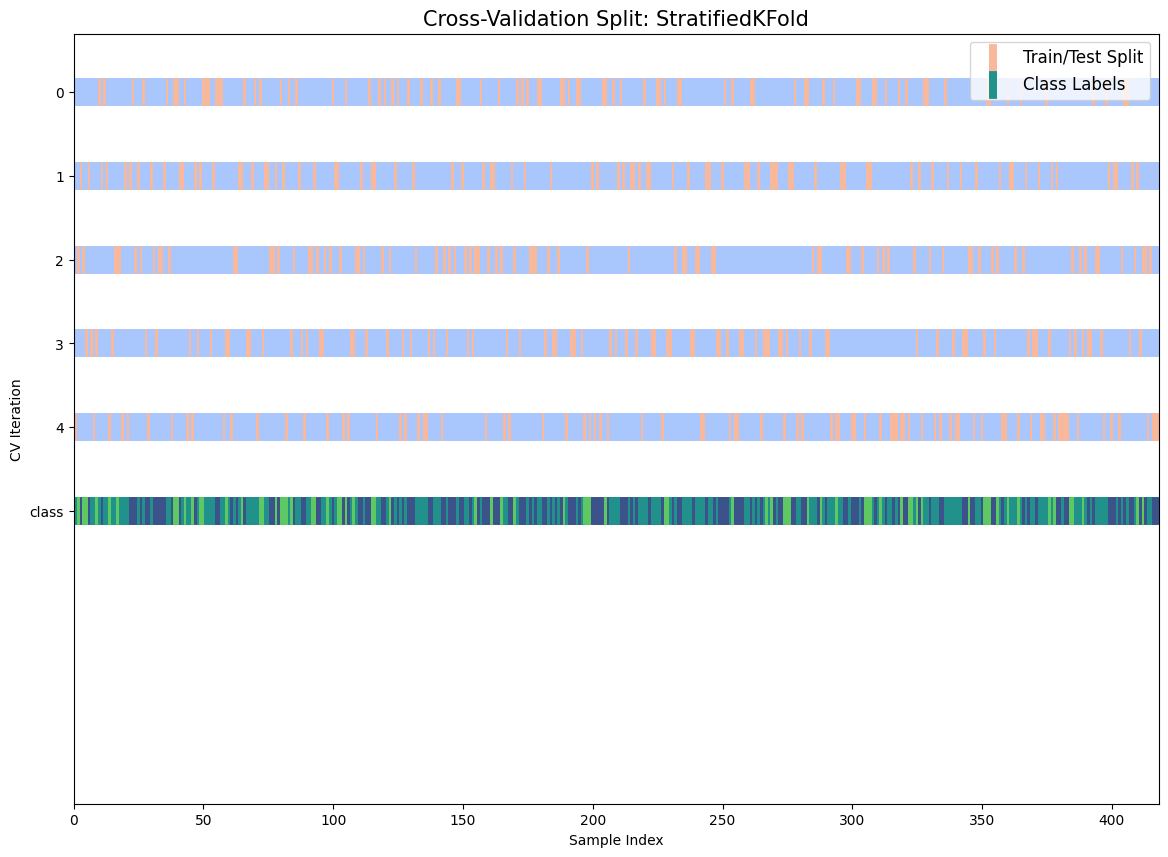

In [ ]:
def plot_cv_indices_with_legends(cv, X, y, ax, n_splits, lw=20):
    """Create a cross-validation plot with legends for more information."""
    for ii, (train_idx, test_idx) in enumerate(cv.split(X=X, y=y)):
        # Create indices array
        indices = np.full(len(X), np.nan)
        indices[test_idx] = 1  # Mark test indices
        indices[train_idx] = 0  # Mark train indices

        # Scatter plot for train/test split indices
        ax.scatter(
            range(len(indices)),
            [ii + 0.5] * len(indices),
            c=indices,
            marker="_",
            lw=lw,
            cmap=cmap_cv,
            vmin=-0.2,
            vmax=1.2,
            label="Train/Test Split" if ii == 0 else None,  # Add to legend once
        )

    # Scatter plot for data classes
    class_plot = ax.scatter(
        range(len(X)), [ii + 1.5] * len(X), c=y, marker="_", lw=lw, cmap=cmap_data, label="Class Labels"
    )

    # Add legends for clarity
    ax.legend(loc="upper right", fontsize=12)

    # Formatting
    yticklabels = list(range(n_splits)) + ["class"]
    ax.set(
        yticks=np.arange(n_splits + 1) + 0.5,
        yticklabels=yticklabels,
        xlabel="Sample Index",
        ylabel="CV Iteration",
        ylim=[n_splits + 4.0, -0.2],
        xlim=[0, len(X)],
    )
    ax.set_title(f"Cross-Validation Split: {type(cv).__name__}", fontsize=15)
    return ax

# Create the plot
fig, ax = plt.subplots(figsize=(14, 10))
plot_cv_indices_with_legends(cv, X, y, ax, n_splits, lw=20)
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# Placeholder for test set metrics
test_accuracies = []
test_precisions = []
test_recalls = []
test_f1_scores = []
test_confusion_matrices = []

# Placeholder for cross-validation metrics
fold_precisions = []
fold_recalls = []
fold_f1_scores = []
fold_confusion_matrices = []
fold_accuracies = []
fold_models = []  # Store models for each fold

# Define Stratified K-Fold as kf
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Loop through the folds
for fold, (train_index, val_index) in enumerate(kf.split(X_train, y_train)):
    # Split the data into training and validation subsets
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    # Train and evaluate the model
    model = LogisticRegression(random_state=42, max_iter=1000)
    model.fit(X_train_fold, y_train_fold)
    fold_models.append(model)

    # Validate and calculate additional metrics for validation set
    y_val_pred = model.predict(X_val_fold)
    accuracy = accuracy_score(y_val_fold, y_val_pred)
    precision = precision_score(y_val_fold, y_val_pred, average="weighted")
    recall = recall_score(y_val_fold, y_val_pred, average="weighted")
    f1 = f1_score(y_val_fold, y_val_pred, average="weighted")
    confusion = confusion_matrix(y_val_fold, y_val_pred)

    fold_accuracies.append(accuracy)
    fold_precisions.append(precision)
    fold_recalls.append(recall)
    fold_f1_scores.append(f1)
    fold_confusion_matrices.append(confusion)

    print(f"Fold {fold + 1} Metrics:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  Confusion Matrix:\n{confusion}\n")

# Calculate average metrics across folds
avg_accuracy = sum(fold_accuracies) / len(fold_accuracies)
avg_precision = sum(fold_precisions) / len(fold_precisions)
avg_recall = sum(fold_recalls) / len(fold_recalls)
avg_f1_score = sum(fold_f1_scores) / len(fold_f1_scores)

print("Average Metrics Across All Folds:")
print(f"  Accuracy: {avg_accuracy:.4f}")
print(f"  Precision: {avg_precision:.4f}")
print(f"  Recall: {avg_recall:.4f}")
print(f"  F1-Score: {avg_f1_score:.4f}")

# Evaluate on the test set using each model
for fold, model in enumerate(fold_models):
    y_test_pred = model.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred, average="weighted")
    test_recall = recall_score(y_test, y_test_pred, average="weighted")
    test_f1 = f1_score(y_test, y_test_pred, average="weighted")
    test_confusion = confusion_matrix(y_test, y_test_pred)

    test_accuracies.append(test_accuracy)
    test_precisions.append(test_precision)
    test_recalls.append(test_recall)
    test_f1_scores.append(test_f1)
    test_confusion_matrices.append(test_confusion)

    print(f"Test Metrics for Model from Fold {fold + 1}:")
    print(f"  Accuracy: {test_accuracy:.4f}")
    print(f"  Precision: {test_precision:.4f}")
    print(f"  Recall: {test_recall:.4f}")
    print(f"  F1-Score: {test_f1:.4f}")
    print(f"  Confusion Matrix:\n{test_confusion}\n")

# Calculate average test metrics
avg_test_accuracy = sum(test_accuracies) / len(test_accuracies)
avg_test_precision = sum(test_precisions) / len(test_precisions)
avg_test_recall = sum(test_recalls) / len(test_recalls)
avg_test_f1_score = sum(test_f1_scores) / len(test_f1_scores)

print("Average Test Metrics Across All Models:")
print(f"  Accuracy: {avg_test_accuracy:.4f}")
print(f"  Precision: {avg_test_precision:.4f}")
print(f"  Recall: {avg_test_recall:.4f}")
print(f"  F1-Score: {avg_test_f1_score:.4f}")


Fold 1 Metrics:
  Accuracy: 0.6866
  Precision: 0.6775
  Recall: 0.6866
  F1-Score: 0.6788
  Confusion Matrix:
[[16  7  2]
 [ 3 25  2]
 [ 5  2  5]]

Fold 2 Metrics:
  Accuracy: 0.6269
  Precision: 0.6761
  Recall: 0.6269
  F1-Score: 0.6291
  Confusion Matrix:
[[18  6  1]
 [11 19  0]
 [ 7  0  5]]

Fold 3 Metrics:
  Accuracy: 0.7015
  Precision: 0.6963
  Recall: 0.7015
  F1-Score: 0.6987
  Confusion Matrix:
[[18  5  3]
 [ 2 24  3]
 [ 6  1  5]]

Fold 4 Metrics:
  Accuracy: 0.6866
  Precision: 0.5799
  Recall: 0.6866
  F1-Score: 0.6277
  Confusion Matrix:
[[20  5  1]
 [ 3 26  0]
 [11  1  0]]

Fold 5 Metrics:
  Accuracy: 0.7424
  Precision: 0.7683
  Recall: 0.7424
  F1-Score: 0.7260
  Confusion Matrix:
[[17  8  1]
 [ 1 28  0]
 [ 2  5  4]]

Average Metrics Across All Folds:
  Accuracy: 0.6888
  Precision: 0.6796
  Recall: 0.6888
  F1-Score: 0.6720
Test Metrics for Model from Fold 1:
  Accuracy: 0.7381
  Precision: 0.7140
  Recall: 0.7381
  F1-Score: 0.7208
  Confusion Matrix:
[[25  3  4]
 [ 